# Credit Card Fraud Detection

## Objective

Build a machine learning model to detect fraudulent credit card transactions.

## Dataset

Credit Card Fraud Detection dataset from Kaggle.

## Approach

- Exploratory Data Analysis
- Data preprocessing
- Handling class imbalance
- Model training
- Model evaluation

Install/import libraries

In [3]:
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

In [1]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


Load the data

In [4]:
df = pd.read_csv("creditcard.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Basic inspection

In [5]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nClass percentages:")
print(df["Class"].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 1. Dataset Overview

Let's examine the dataset structure, data types, and missing values.

In [13]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Dataset Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64


## 2. Statistical Summary

Let's examine the statistical distribution of the numerical features.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 3. Class Distribution

Let's examine the distribution of legitimate and fraudulent transactions.

In [15]:
fraud_counts = df["Class"].value_counts()

print("Legitimate transactions:", fraud_counts[0])
print("Fraudulent transactions:", fraud_counts[1])

print("\nFraud percentage:",
      round((fraud_counts[1] / len(df)) * 100, 4), "%")

Legitimate transactions: 284315
Fraudulent transactions: 492

Fraud percentage: 0.1727 %


## 4. Transaction Amount Distribution

Let's explore how transaction amounts are distributed across the dataset.

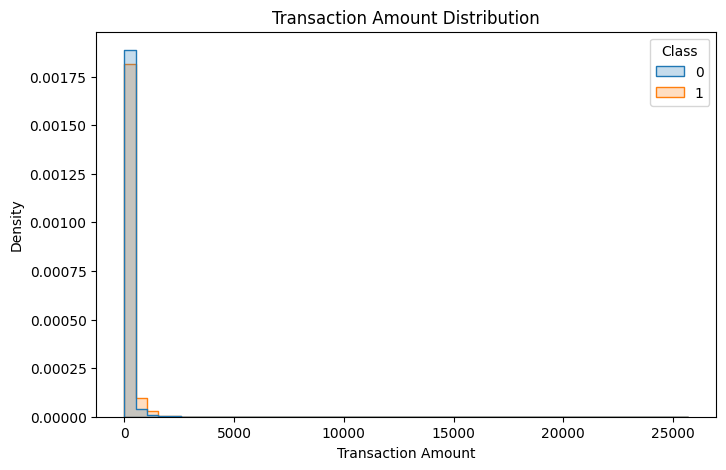

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.show()

## 5. Transaction Amount by Class

Let's compare transaction amounts between legitimate and fraudulent transactions.

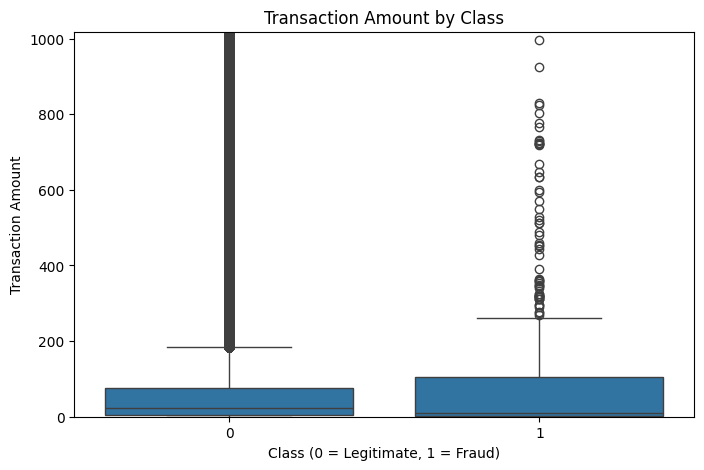

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.ylim(0, df["Amount"].quantile(0.99))

plt.show()

## 6. Feature Correlation

Let's examine which features have stronger relationships with the fraud target.

In [18]:
correlations = df.corr(numeric_only=True)["Class"].sort_values(
    ascending=False
)

print(correlations.head(10))
print("\nLowest correlations:")
print(correlations.tail(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Lowest correlations:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


## 7. Correlation Heatmap

The heatmap provides a visual representation of relationships between the most relevant features.

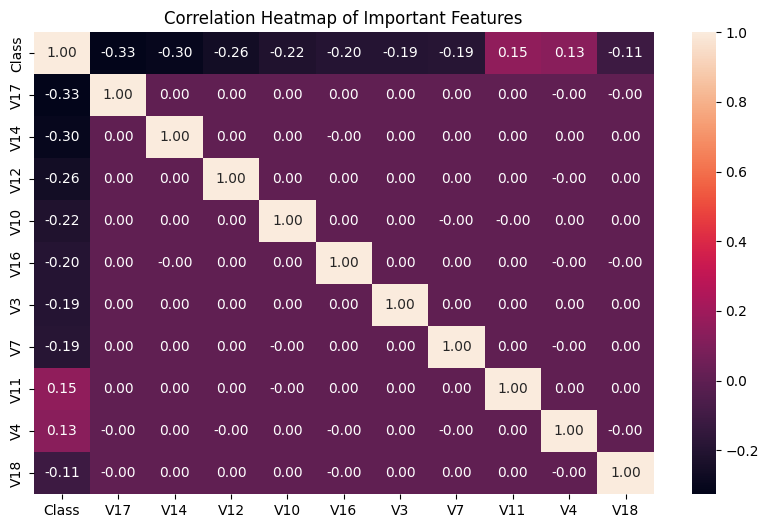

In [19]:
top_features = correlations.abs().sort_values(
    ascending=False
).head(11).index

plt.figure(figsize=(10, 6))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Important Features")
plt.show()

Visualize fraud vs legitimate transactions

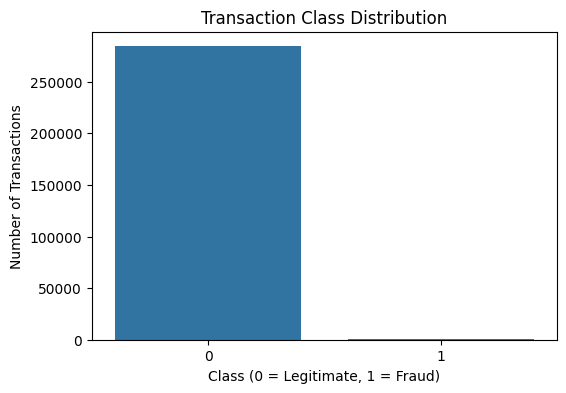

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Class")

plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

## Data Preprocessing and Model Development

After exploring the dataset, the data is prepared for machine learning
and classification models are trained to detect fraudulent transactions.

Prepare the data

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (227845, 30)
Test set: (56962, 30)


Scale Amount and Time

In [8]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

X_train["Time"] = scaler.fit_transform(X_train[["Time"]])
X_test["Time"] = scaler.transform(X_test[["Time"]])

Logistic Regression

In [9]:
model_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)
prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, prob_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9721687370080279


Random Forest

In [10]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)
prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, prob_rf))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.952908497036969


Compare models

In [11]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, prob_lr),
        roc_auc_score(y_test, prob_rf)
    ]
})

results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.060976,0.918367,0.114358,0.972169
1,Random Forest,0.960526,0.744898,0.839080,0.952908


Confusion matrix

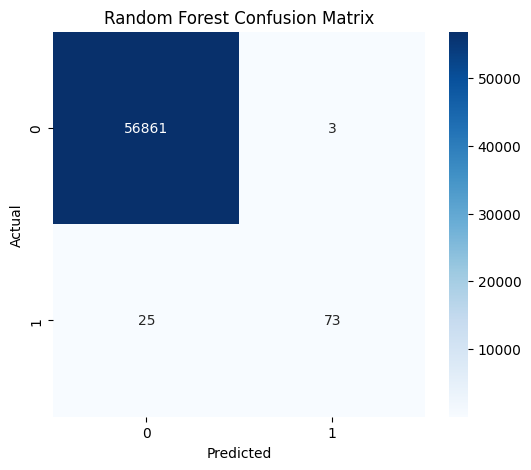

In [12]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Conclusion

This project developed a machine learning pipeline for detecting fraudulent
credit card transactions.

Exploratory data analysis showed that the dataset is highly imbalanced,
with fraudulent transactions representing only a small proportion of the
total transactions.

Logistic Regression and Random Forest were trained and evaluated using
Precision, Recall, F1-score, and ROC-AUC.

Logistic Regression achieved a recall of 91.84%, meaning it detected a high
proportion of fraudulent transactions, but its precision was only 6.10%.

Random Forest achieved a precision of 96.05%, recall of 74.49%, and F1-score
of 83.91%, providing a better balance between precision and recall in this
experiment.

The results demonstrate why accuracy alone is not sufficient for evaluating
models on highly imbalanced fraud detection data.